# CP1 — Araba Fiyatı Tahmini

**Amaç:** Arabanın yaşı, km'si, motoru ve kaçıncı sahibi olduğuna bakarak fiyatını tahmin eden bir model yazmak (sıfırdan, NumPy ile).

## Adım 1: Veriyi tanıyalım

In [1]:
# Kütüphaneleri içeri alıyoruz.
# 'as np' gibi kısaltmalar herkesin kullandığı gelenek: numpy yerine np yazarız.
import numpy as np               # sayılarla / matrislerle hızlı hesap
import pandas as pd              # tablo (CSV) okumak ve düzenlemek
import matplotlib.pyplot as plt  # grafik çizmek

# CSV dosyasını okuyup 'df' adlı bir tabloya koyuyoruz (df = DataFrame = tablo)
df = pd.read_csv("data/Car details v3.csv")

### Görev 1
Aşağıdaki hücreye `df.head()` yaz ve çalıştır (**Shift + Enter**). Ne görüyorsun?

In [2]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


### Görev 2
Şimdi `df.shape` yaz. Çıkan iki sayı ne anlama geliyor olabilir?

In [3]:
df.shape

(8128, 13)

In [4]:
df["age"] = 2026 - df["year"]  # yeni bir sütun ekliyoruz: age = 2026 - year
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,age
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,12
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,12
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,20
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,16
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,19


In [5]:
df["engine"].str.replace("CC", "").astype(float)

0       1248.0
1       1498.0
2       1497.0
3       1396.0
4       1298.0
         ...  
8123    1197.0
8124    1493.0
8125    1248.0
8126    1396.0
8127    1396.0
Name: engine, Length: 8128, dtype: float64

In [6]:
df["engine_cc"] = df["engine"].str.replace("CC", "").astype(float)
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,age,engine_cc
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,12,1248.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,12,1498.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,20,1497.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,16,1396.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,19,1298.0


In [7]:
df["owner_num"] = df["owner"].map({"First Owner": 1, "Second Owner": 2, "Third Owner": 3, "Fourth & Above Owner": 4, "Test Drive Car": 0})
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,age,engine_cc,owner_num
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,12,1248.0,1
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,12,1498.0,2
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,20,1497.0,3
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,16,1396.0,1
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,19,1298.0,1


In [8]:
data = df[["age","km_driven","engine_cc", "owner_num","selling_price"]].dropna()
data.shape

(7907, 5)

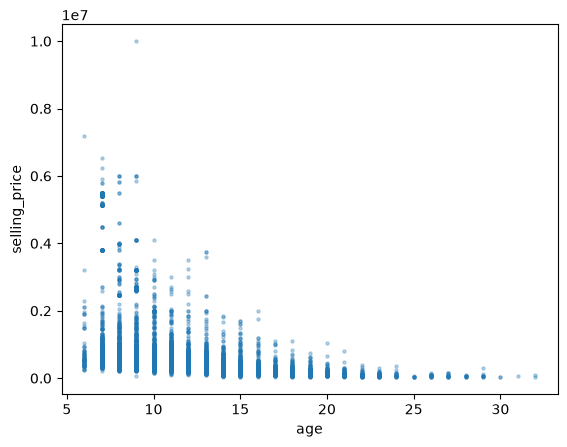

In [9]:
plt.scatter(data["age"], data["selling_price"], s = 5, alpha = 0.3)
plt.xlabel("age")
plt.ylabel("selling_price")
plt.show()

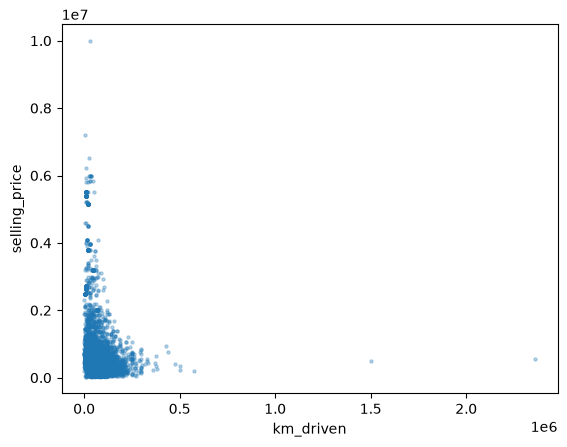

In [10]:
plt.scatter(data["km_driven"], data["selling_price"], s = 5, alpha = 0.3)
plt.xlabel("km_driven")
plt.ylabel("selling_price")
plt.show()

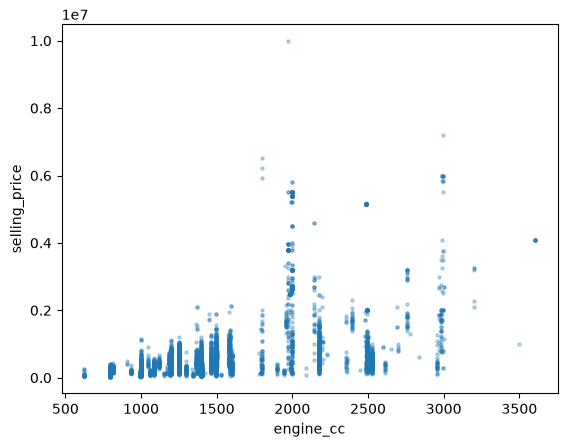

In [11]:
plt.scatter(data["engine_cc"], data["selling_price"], s = 5, alpha = 0.3)
plt.xlabel("engine_cc")
plt.ylabel("selling_price")
plt.show()

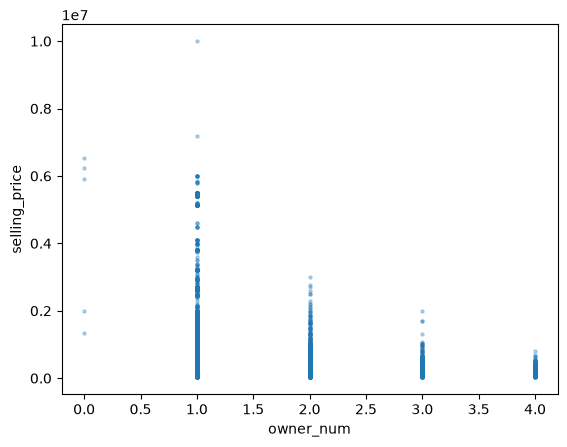

In [12]:
plt.scatter(data["owner_num"], data["selling_price"], s = 5, alpha = 0.3)
plt.xlabel("owner_num")
plt.ylabel("selling_price")
plt.show()

In [13]:
df["power_bhp"] = df["max_power"].str.replace(" bhp", "")
df["power_bhp"] = pd.to_numeric(df["power_bhp"], errors='coerce')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,age,engine_cc,owner_num,power_bhp
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,12,1248.0,1,74.00
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,12,1498.0,2,103.52
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,20,1497.0,3,78.00
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,16,1396.0,1,90.00
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,19,1298.0,1,88.20


In [14]:
data = df[["age","km_driven","engine_cc", "owner_num", "power_bhp", "selling_price"]].dropna()
data.shape

(7906, 6)

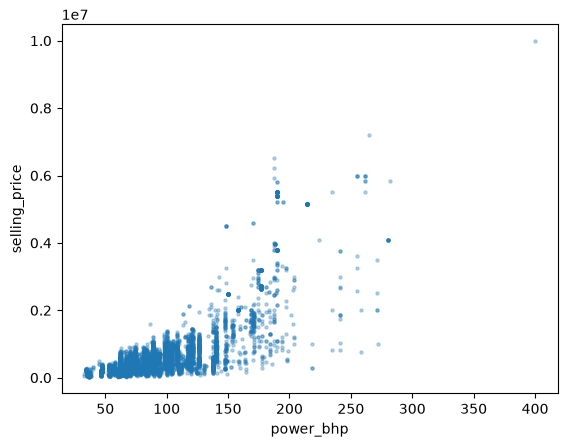

In [15]:
plt.scatter(data["power_bhp"], data["selling_price"], s = 5, alpha = 0.3)
plt.xlabel("power_bhp")
plt.ylabel("selling_price")
plt.show()

In [16]:
x = np.array([2, 5, 10])
y = np.array([900, 600, 200])

prediction = -50 * x + 1000
print(prediction)

[900 750 500]


In [17]:
def compute_cost(x,y,w,b):
    predictions = w * x + b
    error = predictions - y
    cost = (1/(2*len(x))) * np.sum(error**2)
    return cost

print(compute_cost(x,y,-50,1000))
print(compute_cost(x,y,-70,1000))
    

18750.0
2350.0


In [18]:
X = np.array([[2, 100],     # A arabası: 2 yaşında, 100 beygir
              [5, 150],     # B arabası
              [10, 80]])    # C arabası
w = np.array([-50, 2])      # yaşın w'su = -50, beygirin w'su = 2
b = 800

print(X @ w + b)  

[900 850 460]


In [19]:
def compute_cost(X,y,w,b):
    predictions = X @ w + b
    error = predictions - y
    cost = (1/(2*X.shape[0])) * np.sum(error**2)
    return cost

y = np.array([900, 600, 200])
print(compute_cost(X,y,w,b))

21683.333333333332


In [20]:
features = ["age","km_driven","engine_cc", "owner_num", "power_bhp"]
X_train = data[features].to_numpy()
y_train = data["selling_price"].to_numpy()

print(X_train.shape, y_train.shape)
w = np.zeros(5)
b = 0
compute_cost(X_train, y_train, w, b)

(7906, 5) (7906,)


np.float64(542045518428.6275)

In [26]:
def compute_gradient(x,y,w,b):
    predictions = x * w + b
    error = predictions - y
    dj_dw = np.sum(error*x) / len(x)
    dj_db = np.sum(error) / len(x)
    return dj_dw, dj_db

x = np.array([2, 5, 10])
y = np.array([900, 600, 200])
print(compute_gradient(x,y,-50,1000))

(np.float64(1250.0), np.float64(150.0))


In [27]:
def compute_gradient(X,y,w,b):
    predictions = X @ w + b
    error = predictions - y
    dj_dw = X.T @ error / len(X)
    dj_db = np.sum(error) / len(X)
    return dj_dw, dj_db

X = np.array([[2, 100], [5, 150], [10, 80]])
y = np.array([900, 600, 200])
w = np.array([-50, 2])
b = 800
print(compute_gradient(X, y, w, b))

(array([ 1283.33333333, 19433.33333333]), np.float64(170.0))


In [28]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w_in, b_in)
        w_in = w_in - alpha * dj_dw
        b_in = b_in - alpha * dj_db
        
        J_history.append(compute_cost(X, y, w_in, b_in))
    return w_in, b_in, J_history

X = np.array([[2], [5], [10]])
y = np.array([900, 600, 200])
w, b, J_history = gradient_descent(X, y, np.zeros(1), 0, 0.01, 10000)

print(w, b)
print(J_history[0], J_history[-1])

[-86.73469388] 1058.1632652902956
158867.90740740742 153.06122448979636


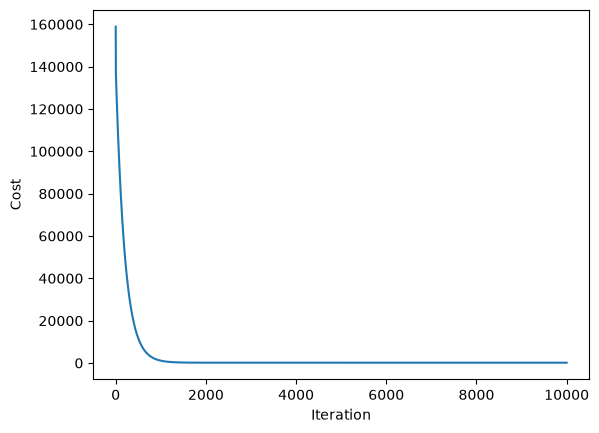

In [29]:
plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")  
plt.show()

In [31]:
w, b, J_hitory = gradient_descent(X_train, y_train, np.zeros(5), 0, 1e-10, 1000)
print(w, b)
print(J_hitory[0], J_hitory[-1])

[2.34008479e-01 3.47254293e+00 6.41195530e+01 2.98828655e-02
 5.21770613e+00] 0.03329262918053794
469801358582.3404 425531723995.20844


In [32]:
def zscore_normalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = zscore_normalize(X_train)
w, b, J_history = gradient_descent(X_norm, y_train, np.zeros(5), 0, 0.1, 1000)
print(w, b)
print(J_history[0], J_history[-1])

[-156320.20324599  -77428.07847973  -32549.60733732  -24472.60010328
  591620.71577831] 649813.7208449272
438973726449.16595 120951335225.81198
